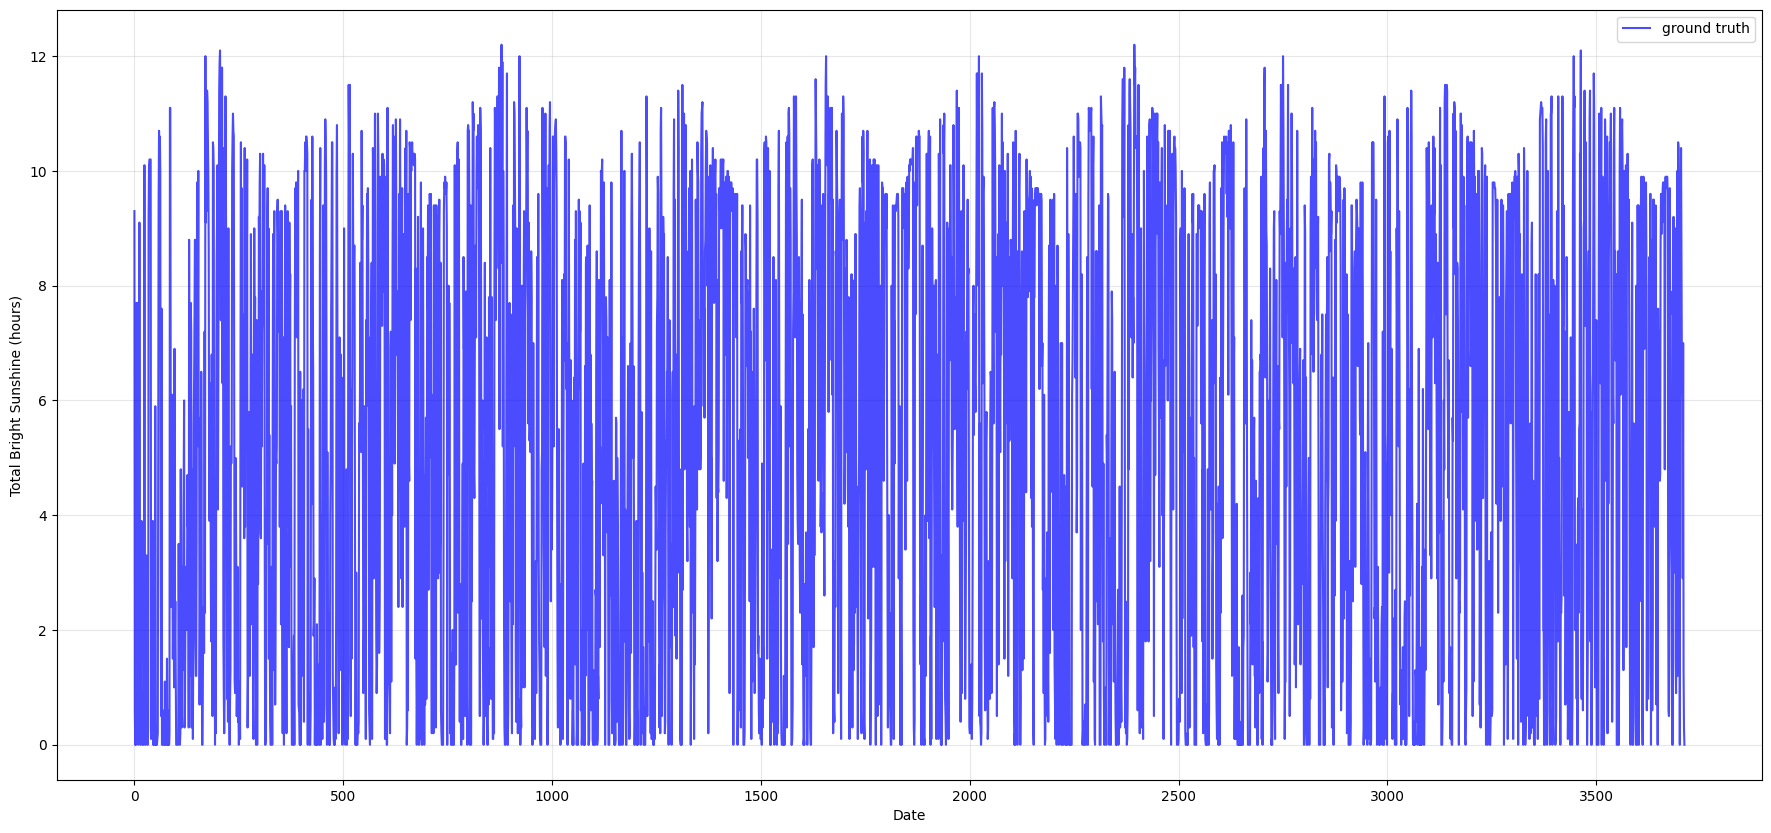

train size: (2964, 5, 1)
test size: (738, 5, 1)
Epoch [10/100], Loss: 0.0686
Epoch [20/100], Loss: 0.0689
Epoch [30/100], Loss: 0.0688
Epoch [40/100], Loss: 0.0686
Epoch [50/100], Loss: 0.0686
Epoch [60/100], Loss: 0.0685
Epoch [70/100], Loss: 0.0684
Epoch [80/100], Loss: 0.0683
Epoch [90/100], Loss: 0.0684
Epoch [100/100], Loss: 0.0682


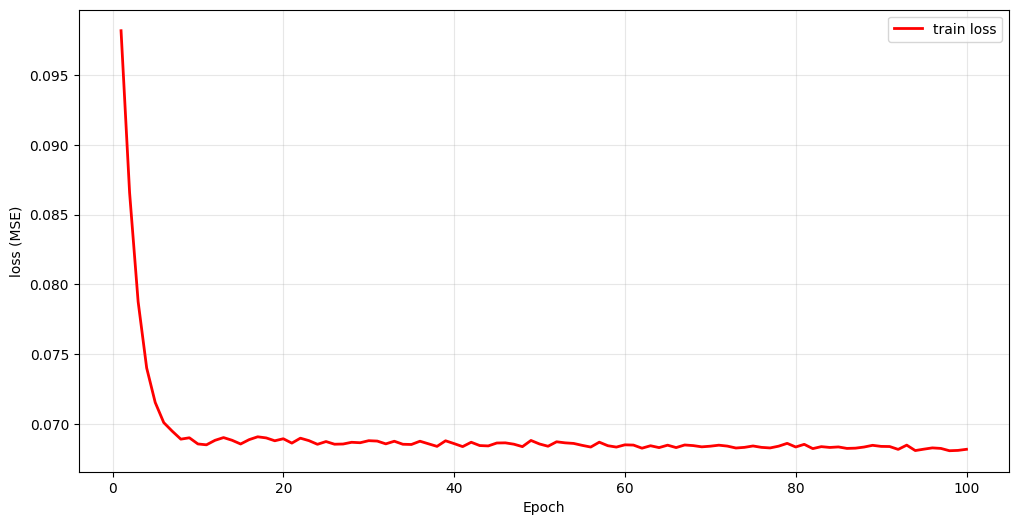

train loss: 0.0679
test loss: 0.0751


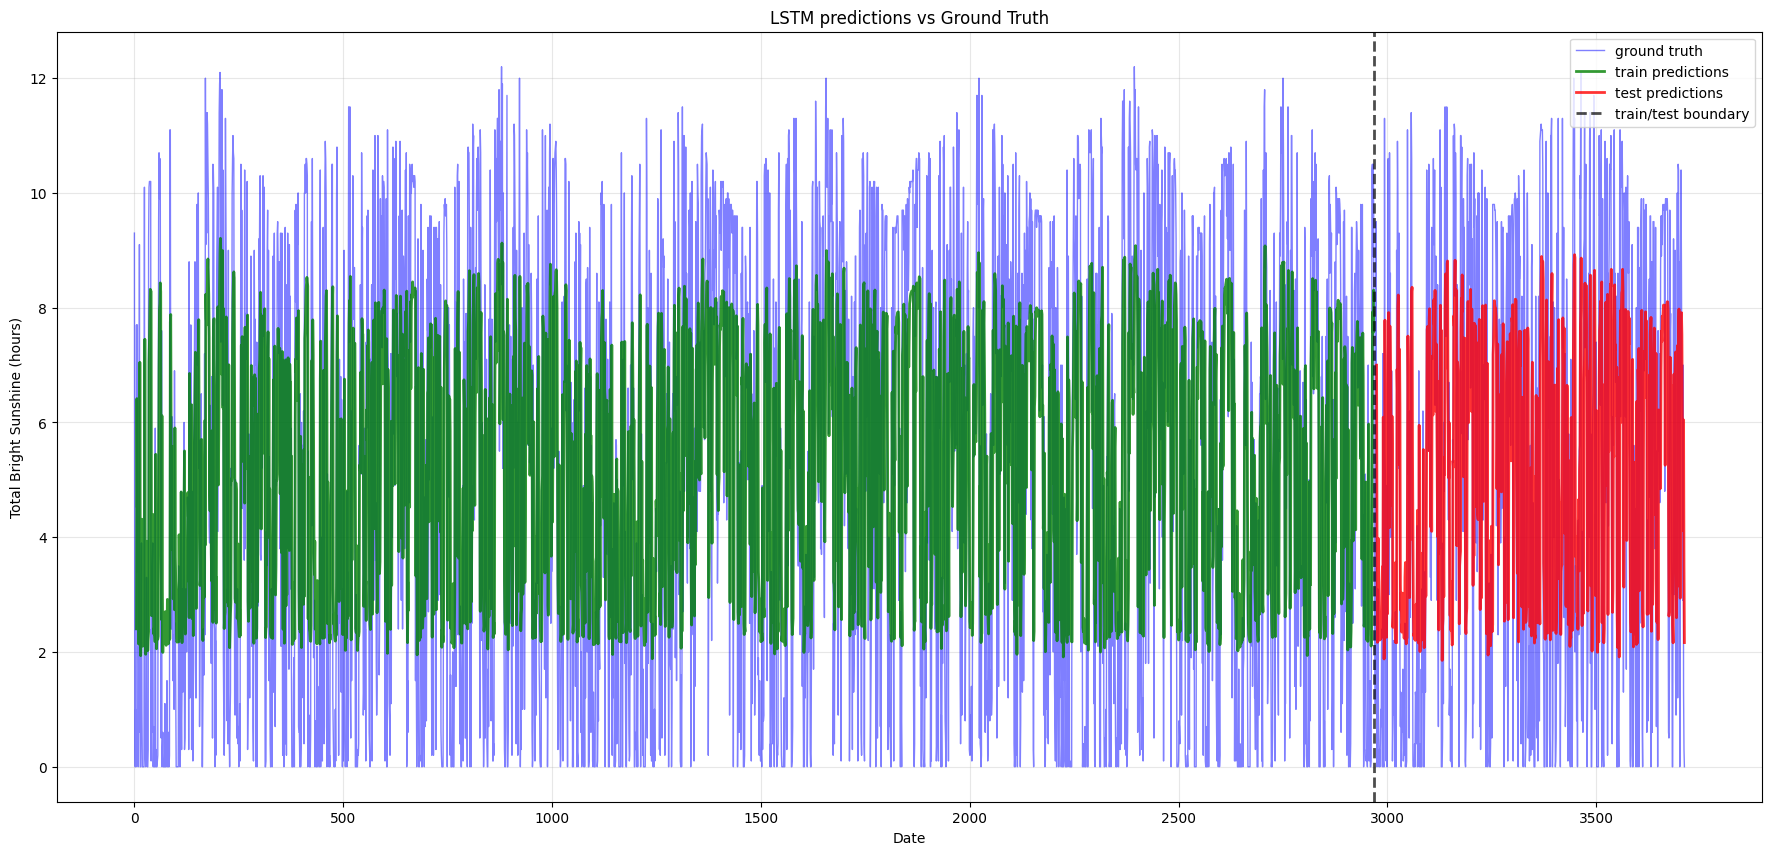

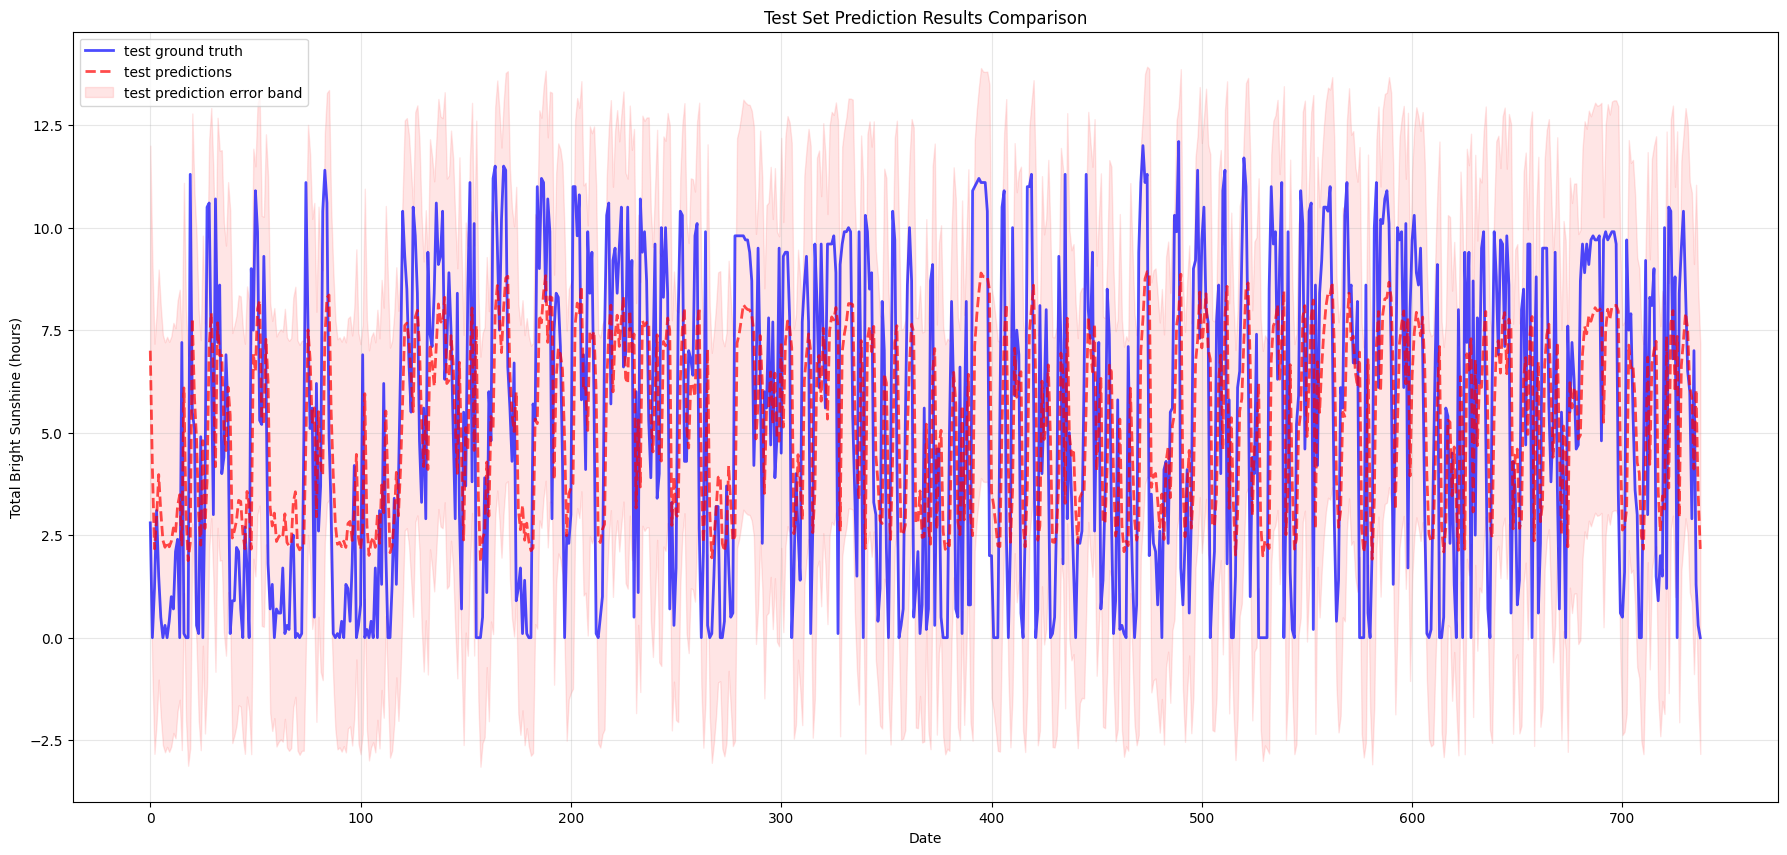

<Figure size 1200x1000 with 0 Axes>

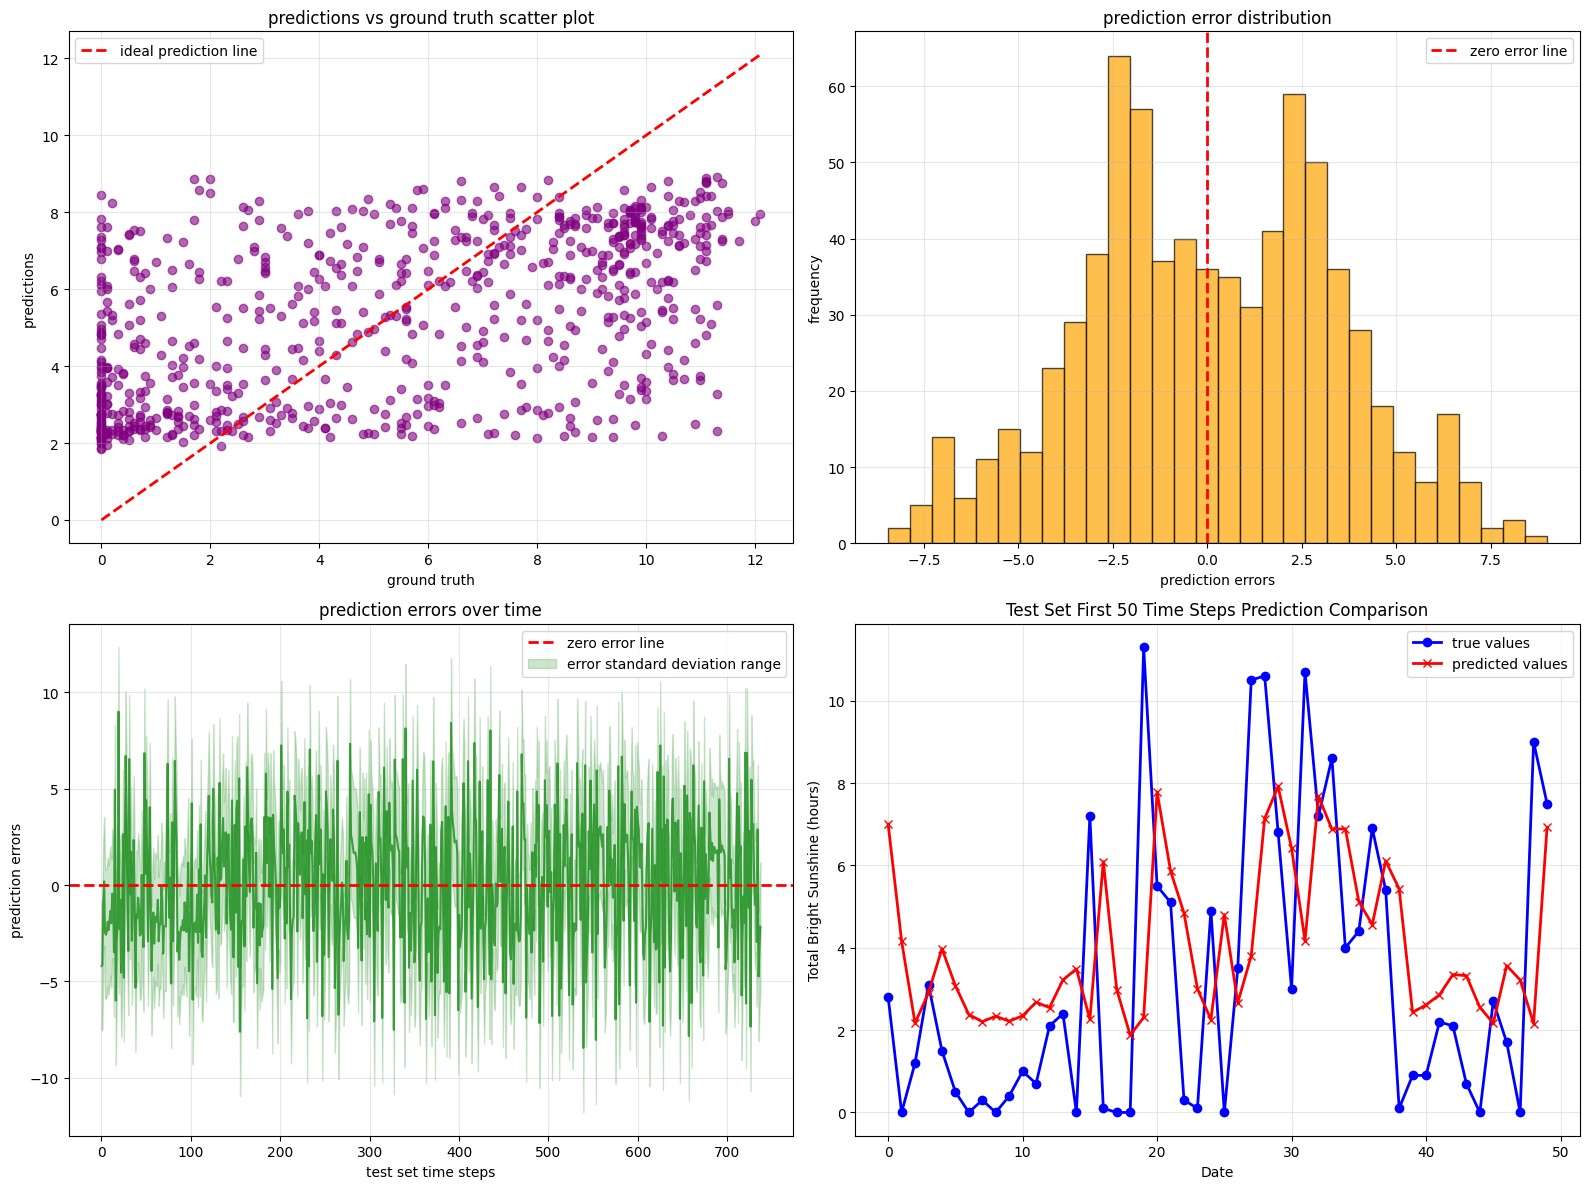


Model Performance Evaluation Metrics:
Mean Squared Error (MSE): 11.1819
Root Mean Squared Error (RMSE): 3.3439
Mean Absolute Error (MAE): 2.7928
R² Score: 0.2629


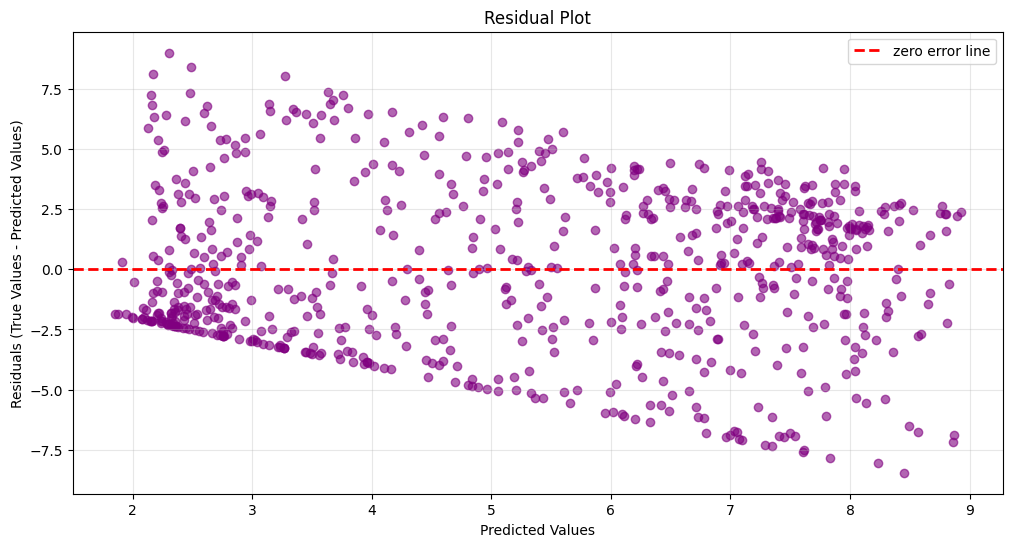

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. 加载和预处理数据
data = pd.read_excel("10 years filled.xlsx")
timeseries = data[["Total Bright Sunshine (hours)"]].values.astype('float32')

# 绘制原始数据
plt.figure(figsize=(22, 10))
plt.plot(timeseries, label='ground truth', color='blue', alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Total Bright Sunshine (hours)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 划分训练集和测试集
train_size = int(len(timeseries) * 0.8)
test_size = len(timeseries) - train_size
train, test = timeseries[:train_size], timeseries[train_size:]

# 数据标准化（重要！LSTM对数据尺度敏感）
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

# 2. 创建时间序列数据集
def create_dataset(dataset, look_back=1):
    """
    将时间序列转换为监督学习数据集
    look_back: 用多少个过去的时间点来预测下一个时间点
    """
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]  # 取look_back个时间点
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])  # 预测下一个时间点
    return np.array(dataX), np.array(dataY)

look_back = 5  # 使用过去5个时间点预测下一个
trainX, trainY = create_dataset(train_scaled, look_back)
testX, testY = create_dataset(test_scaled, look_back)

# 3. 重塑数据形状为 LSTM 需要的格式
# LSTM期望的形状: (samples, time_steps, features)
trainX = np.reshape(trainX, (trainX.shape[0], look_back, 1))
testX = np.reshape(testX, (testX.shape[0], look_back, 1))

print(f"train size: {trainX.shape}")  # 应该是 (n_samples, 5, 1)
print(f"test size: {testX.shape}")

# 4. 转换为PyTorch张量
trainX_tensor = torch.from_numpy(trainX).float()
trainY_tensor = torch.from_numpy(trainY).float().view(-1, 1)  # 将Y重塑为列向量
testX_tensor = torch.from_numpy(testX).float()
testY_tensor = torch.from_numpy(testY).float().view(-1, 1)

# 5. 修正的模型定义
class AirModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,  # 每个时间步的特征数
            hidden_size=hidden_size,  # LSTM隐藏层大小
            num_layers=num_layers,  # LSTM层数
            batch_first=True  # 输入形状为 (batch, seq_len, features)
        )
        self.linear = nn.Linear(hidden_size, 1)  # 输出层
        self.activation = nn.Sigmoid()  # 激活函数
    
    def forward(self, x):
        # LSTM输出: (batch_size, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x)
        # 取最后一个时间步的输出
        last_time_step = lstm_out[:, -1, :]  # 形状: (batch_size, hidden_size)
        # 全连接层
        output = self.linear(last_time_step)
        output = self.activation(output)
        return output

# 6. 创建模型实例
model = AirModel(input_size=1, hidden_size=50)

# 7. 创建数据加载器
batch_size = 32
train_dataset = TensorDataset(trainX_tensor, trainY_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(testX_tensor, testY_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 8. 训练模型
criterion = nn.MSELoss()  # 均方误差损失
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
train_losses = []
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        # 前向传播
        predictions = model(batch_x)
        # 计算损失
        loss = criterion(predictions, batch_y)
        # 反向传播
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # 每个epoch打印损失
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

# 绘制训练损失曲线
plt.figure(figsize=(12, 6))
plt.plot(range(1, num_epochs+1), train_losses, label='train loss', color='red', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 9. 测试模型
model.eval()
with torch.no_grad():
    # 训练集预测
    train_predictions_scaled = model(trainX_tensor)
    train_loss = criterion(train_predictions_scaled, trainY_tensor)
    
    # 测试集预测
    test_predictions_scaled = model(testX_tensor)
    test_loss = criterion(test_predictions_scaled, testY_tensor)
    
    print(f'train loss: {train_loss.item():.4f}')
    print(f'test loss: {test_loss.item():.4f}')

# 10. 反归一化预测结果
# 注意：我们需要将预测结果反归一化回原始尺度
# 首先将预测结果转换为numpy数组
train_predictions_scaled_np = train_predictions_scaled.numpy()
test_predictions_scaled_np = test_predictions_scaled.numpy()

# 反归一化
train_predictions = scaler.inverse_transform(train_predictions_scaled_np)
test_predictions = scaler.inverse_transform(test_predictions_scaled_np)

# 反归一化真实值
trainY_original = scaler.inverse_transform(trainY_tensor.numpy())
testY_original = scaler.inverse_transform(testY_tensor.numpy())

# 11. 可视化预测结果
# 创建时间索引（考虑look_back的偏移）
train_indices = range(look_back, look_back + len(train_predictions))
test_indices = range(train_size + look_back, train_size + look_back + len(test_predictions))

# 绘制整体预测结果
plt.figure(figsize=(22, 10))

# 绘制原始数据
plt.plot(timeseries, label='ground truth', color='blue', alpha=0.5, linewidth=1)

# 绘制训练集预测
plt.plot(train_indices, train_predictions, label='train predictions', color='green', linewidth=2, alpha=0.8)

# 绘制测试集预测
plt.plot(test_indices, test_predictions, label='test predictions', color='red', linewidth=2, alpha=0.8)

# 添加垂直线分隔训练集和测试集
plt.axvline(x=train_size, color='black', linestyle='--', linewidth=2, alpha=0.7, label='train/test boundary')

plt.xlabel("Date")
plt.ylabel("Total Bright Sunshine (hours)")
plt.title("LSTM predictions vs Ground Truth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 12. 单独绘制测试集预测结果对比
plt.figure(figsize=(22, 10))

# 获取测试集原始数据（考虑look_back偏移）
test_original = timeseries[train_size + look_back:]

# 绘制测试集原始数据
plt.plot(range(len(test_original)), test_original, label='test ground truth', color='blue', linewidth=2, alpha=0.7)

# 绘制测试集预测数据
plt.plot(range(len(test_predictions)), test_predictions, label='test predictions', color='red', linewidth=2, alpha=0.7, linestyle='--')

# 添加误差区域
plt.fill_between(range(len(test_predictions)), 
                 test_predictions.flatten() - 5, 
                 test_predictions.flatten() + 5, 
                 color='red', alpha=0.1, label='test prediction error band')

plt.xlabel("Date")
plt.ylabel("Total Bright Sunshine (hours)")
plt.title("Test Set Prediction Results Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 13. 绘制预测误差散点图
plt.figure(figsize=(12, 10))

# 计算预测误差
test_errors = test_original.flatten() - test_predictions.flatten()

# 创建子图
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 子图1: 预测值与真实值散点图
axes[0, 0].scatter(test_original, test_predictions, alpha=0.6, color='purple')
axes[0, 0].plot([test_original.min(), test_original.max()], 
                [test_original.min(), test_original.max()], 
                'r--', linewidth=2, label='ideal prediction line')
axes[0, 0].set_xlabel('ground truth')
axes[0, 0].set_ylabel('predictions')
axes[0, 0].set_title('predictions vs ground truth scatter plot')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 子图2: 预测误差分布直方图
axes[0, 1].hist(test_errors, bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='zero error line')
axes[0, 1].set_xlabel('prediction errors')
axes[0, 1].set_ylabel('frequency')
axes[0, 1].set_title('prediction error distribution')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 子图3: 预测误差随时间变化
axes[1, 0].plot(range(len(test_errors)), test_errors, color='green', alpha=0.7)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='zero error line')
axes[1, 0].fill_between(range(len(test_errors)), 
                        test_errors - np.std(test_errors), 
                        test_errors + np.std(test_errors), 
                        color='green', alpha=0.2, label='error standard deviation range')
axes[1, 0].set_xlabel('test set time steps')
axes[1, 0].set_ylabel('prediction errors')
axes[1, 0].set_title('prediction errors over time')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 子图4: 预测值与真实值对比（前50个点）
n_points = min(50, len(test_predictions))
axes[1, 1].plot(range(n_points), test_original[:n_points], label='true values', color='blue', linewidth=2, marker='o')
axes[1, 1].plot(range(n_points), test_predictions[:n_points], label='predicted values', color='red', linewidth=2, marker='x')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Total Bright Sunshine (hours)')
axes[1, 1].set_title('Test Set First 50 Time Steps Prediction Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 14. 计算并打印评估指标
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 计算评估指标
mse = mean_squared_error(test_original, test_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_original, test_predictions)
r2 = r2_score(test_original, test_predictions)

print("\n" + "="*50)
print("Model Performance Evaluation Metrics:")
print("="*50)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print("="*50)

# 15. 绘制残差图
plt.figure(figsize=(12, 6))
plt.scatter(test_predictions, test_errors, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='zero error line')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (True Values - Predicted Values)')
plt.title('Residual Plot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()